In [1]:
import sympy as sp
sp.init_printing(use_unicode=True)
from sympy.codegen.ast import real, float64

In [2]:
# Forward Dynamics
# from sympy.physics.mechanics import dynamicsymbols, init_vprinting

# l1, l2, l3, r4 = symbols('l1 l2 l3 r4')
# t = symbols('t')
# m, g = symbols('m g')


# def fk(th1, th2, th3):
#     th4 = -(th3 + th2)
#     h = l2 * sin(th2) + l3 * sin(th4)
#     s1 = sin(th1)
#     c1 = cos(th1)

#     p = Matrix([0, 0, 0])
#     p[0] = -l2 * cos(th2) + l3 * cos(th4)
#     p[1] = l1 * c1 - h * s1
#     p[2] = l1 * s1 + h * c1 + r4
#     return p


# theta1, theta2, theta3 = dynamicsymbols('theta1 theta2 theta3')
# dtheta1 = diff(theta1, t)
# dtheta2 = diff(theta2, t)
# dtheta3 = diff(theta3, t)
# h = -fk(theta1, theta2, theta3)[2].simplify()
# v = diff(fk(theta1, theta2, theta3), t)
# v2 = v.dot(v).simplify()
# init_vprinting()
# display(h)
# display(v2)
# T = Rational(1, 2) * m * v2
# V = m * g * h
# L = (T - V).simplify()
# display(L)
# (diff(diff(L, dtheta1), t) - diff(L, theta1)).simplify()

In [3]:
l1, l2, l3 = sp.symbols("l[0] l[1] l[2]", positive=True)
x, y, z = sp.symbols("x y z", real=True)
th1 = sp.atan2(z, y)-sp.acos(l1/sp.sqrt(y**2+z**2))
z_proj = sp.sqrt(z**2+y**2-l1**2)
d2 = x**2+z_proj**2
th2 = sp.atan2(z_proj, x)-sp.acos((l2**2+d2-l3**2)/(2*l2*sp.sqrt(d2)))
th3 = -sp.acos((l2**2+l3**2-d2)/(2*l2*l3))

p = sp.symbols('|p|^2')
l = sp.symbols('|l|^2')
d2sym = sp.symbols('d2')
z_projsym = sp.symbols(r'zproj')
replace_dict = {
    z_proj: z_projsym,
    d2: d2sym
}

X = sp.Matrix([x, y, z])
Theta = sp.Matrix([th1, th2, th3])
# .subs({l1: 0.01, l2: 0.01})
J = Theta.jacobian(X).subs(replace_dict)

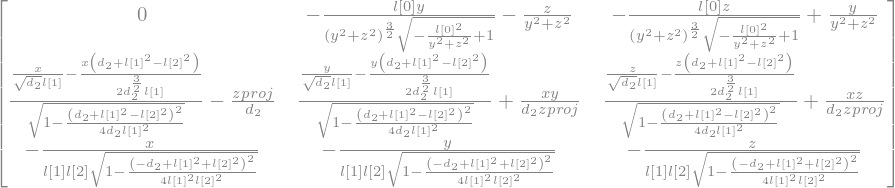

In [4]:
display(J)

In [5]:
for i in range(3):
  for j in range(3):
    print(sp.ccode(J[i,j], assign_to=f"J({i},{j})", type_aliases={real: float64}))


J(0,0) = 0;
J(0,1) = -l[0]*y/(pow(pow(y, 2) + pow(z, 2), 3.0/2.0)*sqrt(-pow(l[0], 2)/(pow(y, 2) + pow(z, 2)) + 1)) - z/(pow(y, 2) + pow(z, 2));
J(0,2) = -l[0]*z/(pow(pow(y, 2) + pow(z, 2), 3.0/2.0)*sqrt(-pow(l[0], 2)/(pow(y, 2) + pow(z, 2)) + 1)) + y/(pow(y, 2) + pow(z, 2));
J(1,0) = (x/(sqrt(d2)*l[1]) - 1.0/2.0*x*(d2 + pow(l[1], 2) - pow(l[2], 2))/(pow(d2, 3.0/2.0)*l[1]))/sqrt(1 - 1.0/4.0*pow(d2 + pow(l[1], 2) - pow(l[2], 2), 2)/(d2*pow(l[1], 2))) - zproj/d2;
J(1,1) = (y/(sqrt(d2)*l[1]) - 1.0/2.0*y*(d2 + pow(l[1], 2) - pow(l[2], 2))/(pow(d2, 3.0/2.0)*l[1]))/sqrt(1 - 1.0/4.0*pow(d2 + pow(l[1], 2) - pow(l[2], 2), 2)/(d2*pow(l[1], 2))) + x*y/(d2*zproj);
J(1,2) = (z/(sqrt(d2)*l[1]) - 1.0/2.0*z*(d2 + pow(l[1], 2) - pow(l[2], 2))/(pow(d2, 3.0/2.0)*l[1]))/sqrt(1 - 1.0/4.0*pow(d2 + pow(l[1], 2) - pow(l[2], 2), 2)/(d2*pow(l[1], 2))) + x*z/(d2*zproj);
J(2,0) = -x/(l[1]*l[2]*sqrt(1 - 1.0/4.0*pow(-d2 + pow(l[1], 2) + pow(l[2], 2), 2)/(pow(l[1], 2)*pow(l[2], 2))));
J(2,1) = -y/(l[1]*l[2]*sqrt(1 - 